# Basic RAG vs Graph RAG — Interactive Walkthrough

This notebook walks through one PDF document processed two different ways:

1. **Basic RAG** — chunk the text, retrieve by similarity, answer from chunks
2. **Graph RAG** — extract a knowledge graph, retrieve by traversing relationships, answer from facts

By the end you'll see, on the *same questions*, what each approach retrieves and why one gives a better answer.

> Runs fully offline by default (mock extractor/agent). Set `OPENAI_API_KEY` before launching Jupyter to use real OpenAI calls instead — no code changes needed, every function auto-detects the key.


In [1]:
import os
from pipeline import read_pdf_text, render_graph
from basic_rag import chunk_text, BasicRAGIndex, answer_with_basic_rag
from graph_rag import load_org_graph, GraphRAGIndex, answer_with_graph_rag

USING_OPENAI = bool(os.environ.get("OPENAI_API_KEY"))
print("Mode:", "REAL OpenAI calls" if USING_OPENAI else "OFFLINE mock mode (no OPENAI_API_KEY set)")


Mode: OFFLINE mock mode (no OPENAI_API_KEY set)


## 1. The source document

`company_overview.pdf` describes a small fictional company, **Northwind Robotics** — 10 people, their roles, who reports to whom, and who collaborates with whom. Everything below is derived from this one document.


In [2]:
text = read_pdf_text("company_overview.pdf")
print(f"{len(text)} characters extracted.\n")
print(text[:600] + " ...")


1173 characters extracted.

Northwind Robotics — Company Overview
Northwind Robotics is a mid-sized robotics company organized into three departments: Engineering,
Sales, and Operations.
Priya Sharma is the Chief Executive Officer of Northwind Robotics. She directly oversees Arjun Mehta,
who leads the Engineering department as VP of Engineering, and Lisa Chen, who leads the Sales
department as VP of Sales.
Arjun Mehta manages two engineers: Ravi Kumar, a Senior Software Engineer, and Meera Iyer, a
Robotics Hardware Engineer. Ravi Kumar and Meera Iyer collaborate closely on the AtlasBot product
line.
Lisa Chen manages Dav ...


## 2. Basic RAG: chunk it, embed it, retrieve by similarity

This is the standard RAG baseline: split the document into fixed-size text windows, vectorize them (TF-IDF here, standing in for dense embeddings), and at query time retrieve whichever chunks are textually most similar to the question.


In [3]:
chunks = chunk_text(text, sentences_per_chunk=2)
print(f"{len(chunks)} chunks created:\n")
for i, c in enumerate(chunks):
    print(f"[{i}] {c}")


6 chunks created:

[0] Northwind Robotics — Company Overview Northwind Robotics is a mid-sized robotics company organized into three departments: Engineering, Sales, and Operations. Priya Sharma is the Chief Executive Officer of Northwind Robotics.
[1] She directly oversees Arjun Mehta, who leads the Engineering department as VP of Engineering, and Lisa Chen, who leads the Sales department as VP of Sales. Arjun Mehta manages two engineers: Ravi Kumar, a Senior Software Engineer, and Meera Iyer, a Robotics Hardware Engineer.
[2] Ravi Kumar and Meera Iyer collaborate closely on the AtlasBot product line. Lisa Chen manages David Wong, an Account Executive, and Fatima Noor, a Sales Operations Analyst.
[3] David Wong regularly coordinates with Ravi Kumar on product demos for enterprise clients. Operations is led by Carlos Rivera, Director of Operations, who reports directly to Priya Sharma.
[4] Carlos Rivera manages Sana Aziz, the Logistics Coordinator. Sana Aziz works with Meera Iyer to sc

In [4]:
basic_index = BasicRAGIndex(chunks)
print("Basic RAG index built (TF-IDF over", len(chunks), "chunks).")


Basic RAG index built (TF-IDF over 6 chunks).


## 3. Graph RAG: extract entities + relationships into a graph

Instead of indexing raw text, we ask an LLM (or, offline, a rule-based mock) to pull out **people, roles, and relationships** as structured data, then build a graph out of it. Retrieval becomes *graph traversal* instead of *text similarity*.


In [5]:
org_graph = load_org_graph("company_overview.pdf")
print(f"Graph built: {org_graph.number_of_nodes()} nodes, {org_graph.number_of_edges()} edges")
print("\nNodes:", list(org_graph.nodes(data="role")))


[extract] No OPENAI_API_KEY set — using offline mock extractor.
Graph built: 10 nodes, 13 edges

Nodes: [('Priya Sharma', 'CEO'), ('Arjun Mehta', 'VP of Engineering'), ('Lisa Chen', 'VP of Sales'), ('Ravi Kumar', 'Senior Software Engineer'), ('Meera Iyer', 'Robotics Hardware Engineer'), ('David Wong', 'Account Executive'), ('Fatima Noor', 'Sales Operations Analyst'), ('Carlos Rivera', 'Director of Operations'), ('Sana Aziz', 'Logistics Coordinator'), ('Tom Becker', 'Engineering Intern')]


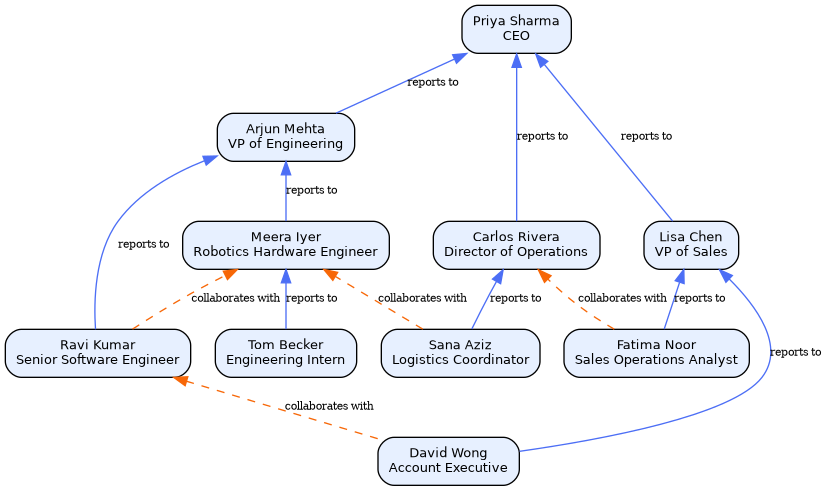

In [6]:
img_path = render_graph(org_graph, "org_graph.png")
from IPython.display import Image, display
display(Image(filename=img_path))


In [7]:
graph_index = GraphRAGIndex(org_graph)
print("Graph RAG index ready.")


Graph RAG index ready.


## 4. Head-to-head: same question, two retrieval strategies

Let's start with one question and look at exactly what each approach retrieves before it answers.


In [8]:
question = "How is Tom Becker connected to Priya Sharma?"

basic_result = answer_with_basic_rag(basic_index, question, k=2)
graph_result = answer_with_graph_rag(graph_index, question, hops=1)

print("QUESTION:", question)
print()
print("BASIC RAG retrieved chunks:")
for chunk, score in basic_result["retrieved_context"]:
    print(f"  (score={score:.3f}) {chunk}")
print("\nBASIC RAG answer:")
print(" ", basic_result["answer"])

print()
print("GRAPH RAG retrieved facts:")
for fact in graph_result["retrieved_context"]:
    print("  -", fact)
print("\nGRAPH RAG answer:")
print(" ", graph_result["answer"])


QUESTION: How is Tom Becker connected to Priya Sharma?

BASIC RAG retrieved chunks:
  (score=0.314) Fatima Noor partners with Carlos Rivera on quarterly demand forecasting. Meera Iyer also mentors an intern, Tom Becker, who is part of the Engineering department.
  (score=0.185) David Wong regularly coordinates with Ravi Kumar on product demos for enterprise clients. Operations is led by Carlos Rivera, Director of Operations, who reports directly to Priya Sharma.

BASIC RAG answer:
  Meera Iyer also mentors an intern, Tom Becker, who is part of the Engineering department.

GRAPH RAG retrieved facts:
  - Arjun Mehta reports to Priya Sharma.
  - Meera Iyer reports to Arjun Mehta.
  - Tom Becker reports to Meera Iyer.

GRAPH RAG answer:
  Arjun Mehta reports to Priya Sharma. Meera Iyer reports to Arjun Mehta. Tom Becker reports to Meera Iyer.


Notice: the full chain **Tom Becker → Meera Iyer → Arjun Mehta → Priya Sharma** is never written as one sentence anywhere in the source PDF. Graph RAG reconstructs it correctly by walking `reports_to` edges. Basic RAG can only retrieve whichever chunk *sounds* most similar to the question — which is not the same as containing the multi-hop answer.


## 5. Full comparison across question types

Now let's run a mixed set of questions — simple lookup, single-hop, multi-hop, and aggregation — through both pipelines, to see the pattern generalize.


In [9]:
from compare_rag import DEMO_QUESTIONS
import textwrap

for item in DEMO_QUESTIONS:
    q = item["question"]
    print("=" * 90)
    print("QUESTION:", q)
    print("TYPE:", item["type"])
    print("-" * 90)

    b = answer_with_basic_rag(basic_index, q, k=2)
    g = answer_with_graph_rag(graph_index, q, hops=1)

    print("[BASIC RAG] answer: ", b["answer"])
    print("[GRAPH RAG] answer: ", g["answer"])
    print()
    print("WHY:", textwrap.fill(item["why"], width=88))
    print()


QUESTION: What is Ravi Kumar's role?
TYPE: Simple factual lookup
------------------------------------------------------------------------------------------
[BASIC RAG] answer:  Ravi Kumar and Meera Iyer collaborate closely on the AtlasBot product line.
[GRAPH RAG] answer:  David Wong collaborates with Ravi Kumar. Meera Iyer reports to Arjun Mehta. Ravi Kumar collaborates with Meera Iyer. Ravi Kumar is a Senior Software Engineer. Ravi Kumar reports to Arjun Mehta.

WHY: The fact sits in a single sentence, so both approaches usually get it.

QUESTION: Who does Ravi Kumar report to?
TYPE: Single-hop relationship
------------------------------------------------------------------------------------------
[BASIC RAG] answer:  Ravi Kumar and Meera Iyer collaborate closely on the AtlasBot product line.
[GRAPH RAG] answer:  David Wong collaborates with Ravi Kumar. Meera Iyer reports to Arjun Mehta. Ravi Kumar collaborates with Meera Iyer. Ravi Kumar is a Senior Software Engineer. Ravi Kumar repo

## 6. Takeaways for learners

| | Basic RAG | Graph RAG |
|---|---|---|
| Retrieves | Text chunks (similarity search) | Facts/triples (graph traversal) |
| Great for | Single-fact lookups contained in one chunk | Multi-hop questions, aggregation, relationship reasoning |
| Weak spot | Multi-hop and aggregation questions — the answer is split across chunks that don't all get retrieved together | Anything not modeled as an explicit entity/relationship during extraction |
| Failure mode | Retrieves text that *sounds* relevant but doesn't contain the answer | Misses a relationship the extraction step failed to capture |

**Core idea to leave learners with:** Basic RAG asks *"what text looks like this question?"* Graph RAG asks *"what facts are structurally connected to what this question is about?"* The second question scales much better once your use case involves relationships — fraud rings, claim-provider-patient chains, org structures, supply chains, etc.

### Adapting this to your own domain
Swap `company_overview.pdf` for your domain document, update the extraction schema in `pipeline.py`, and reuse everything else unchanged. See `README.md` section 7 for the full checklist.
